<a href="https://colab.research.google.com/github/abegyaberhanu/Abby-s_Portfolio/blob/main/Exercise_8_Model_Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predicting Customer  Retention

## Importing

#### Importing code from the public library

In [ ]:
# import all the libraries of code from python to reduce size of file and increase efficiency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline


# Import specific funtions from differnt libraries so we don't have to import whole
# libraries to reduce computational power needed
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

#### Importing file




In [ ]:

# create a datafram object and input the datapoints from the file
# Because this object is different dementions, we are able to read whole
# files into the variable
dataset = pd.read_csv('/content/Churn.csv')

## Summary

In [ ]:
# We can get a quick idea of how many rows and columns the data
#contains with the shape property.
print ("Rows and Columns of dataset: ", dataset.shape, "\n")

#this shows us the top 10 rows of the file
dataset.head(10)

Rows and Columns of dataset:  (667, 16) 



,Account length,Area code,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,117,408,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,65,415,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,161,415,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,111,415,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,49,510,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False
5,36,408,146.3,128,24.87,162.5,80,13.81,129.3,109,5.82,14.5,6,3.92,0,False
6,65,415,211.3,120,35.92,162.6,122,13.82,134.7,118,6.06,13.2,5,3.56,3,False
7,119,415,159.1,114,27.05,231.3,117,19.66,143.2,91,6.44,8.8,3,2.38,5,True
8,10,408,186.1,112,31.64,190.2,66,16.17,282.8,57,12.73,11.4,6,3.08,2,False
9,68,415,148.8,70,25.30,246.5,164,20.95,129.8,103,5.84,12.1,3,3.27,3,False


In [ ]:
#This checks if there are missing values in the dataset
dataset.isnull().any().any()

np.False_

In [ ]:
#Displays different informaiton of the dataset for each column
dataset.describe()

,Account length,Area code,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


## Data Preparation

####Spliting variables

In [ ]:
#We can create variables that have different combinations of the columns to see
# if we can identify combinations that have higher effect on the predicting customer retention

dataset_charges = dataset.filter(["Total day charge", "Total eve charge", "Total night charge", "Churn"])

dataset_callMin = dataset.filter(["Total day minutes", "Total eve minutes", "Total night minutes", "Churn"])

dataset_callCount = dataset.filter(["Total day calls", "Total eve calls", "Total night calls", "Churn"])

dataset_durationAndCharge = dataset.filter(["Total day charge", "Total eve charge",
  "Total night charge","Total day minutes", "Total eve minutes", "Total night minutes", "Churn"
    ])


In [ ]:
#Now we want to split the data into the independent and dependent variables
#We want to create a model that will predict the chaances of a customer  churning or
# not so we asre making that the dependent and every other variable is going to
# be the independent variables that could affect the churning of

#The independent variables are all rows except the last and this selects them all
X = dataset.iloc[:, 0:15].values

#the dependent variable is the last column and this just select the last column
y = dataset.iloc[:, 15].values


# IMPORTANT: we can change the dataset.iloc to different datasets we filtered to build
#           models with different independent variables and see how that efffect the accuracy
# * the braket values need to be changed to reflect the number of new variables

####Encoding

In [ ]:
#Because the values in the Churn column are boolean strings we want to change
# the values to 1 or 0 so it's easier to handel
# we already imported the function we can use to change the values called LabelEncoder

#Prints the unchanged values of True and False Values
print (y)

le = LabelEncoder()
y = le.fit_transform(y)

#Prints the values changed to binary values that are easy to manage
print(y)

[False  True  True False False False False  True False False False False
 False False  True False  True False False False False False False False
 False False False False False False False False False False False  True
 False False False False False  True False False False False False  True
 False False False False  True False False False  True False  True False
  True  True  True False False  True False False False False False False
 False False  True False False False False False False False False False
 False False False False False False False False False False False False
  True False  True False  True False False False False False False False
 False  True  True False False False  True  True False False False False
 False False False  True False False False False False False False False
  True False  True False False False False False False False False False
 False False False False False False False False False False  True  True
 False False False False False False False  True Fa

####Spliting data Values

In [ ]:
#Now we want to split the data into testing and training data

# Python has a function that we imported that can slice the data we select into
# testing and traning data so the model is built on a portion of the data and
# then we test the built model with the rest of the data it hasn't seen to check
# for accuracy.
# Here we are specifying 80% of the datapoints randomly selected to be the
# Traning portion

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=0)

#Prints the rows and columns of the independent variable's test values
print("Testing data", X_test.shape)

#Prints the rows and columns of the independent variable's train values
print("Training data", X_train.shape)

Testing data (134, 15)
Training data (533, 15)


#### Feature Scaling
Feature scaling helps makes sure we are comparing the values of columns as the same weight because we don't want to compare the count of Customer service calls	which would be vastly smaller than the duration of calls.
* Feature scalling also makes the units uniform because we don't want to compare apples to oranges


In [ ]:
#We are going to use a function we already imported to standardize the training
# and testing data values

#The first row of values before scaling
print ("Before scaling too standard: \n ", X_test[0], "\n")

#Scaling to the same unites
scaler = StandardScaler()
scaler.fit (X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#The first row of values after scaling
print ("After scaling to standard: \n", X_test[0])


Before scaling too standard: 
  [136.   415.   163.4   83.    27.78 249.3  119.    21.19 249.7   90.
  11.24   9.8    4.     2.65   7.  ] 

After scaling to standard: 
 [ 0.77674151 -0.5218076  -0.33745477 -0.86566504 -0.33729923  0.92145722
  0.99293613  0.921313    1.03429303 -0.50828221  1.03573625 -0.12137051
 -0.21053084 -0.1168901   4.08180342]


## Data Visualization  

### Importance of Visualization
 Befor we build the model, we can use different graphs to visualize our data so we can have some sense of what the values look like.
 Visualization can also help us have an idea of what variables might have the most impact on the dependent variable and should be included in the model as features that guild the prediction.

#### Parallel Coordinates Plot
This graph is going to plot each instance of observation as a continous line across the variables and will color code the outcome so we can see if we can identify variables where the value might have a higher impact on the dependent variable.

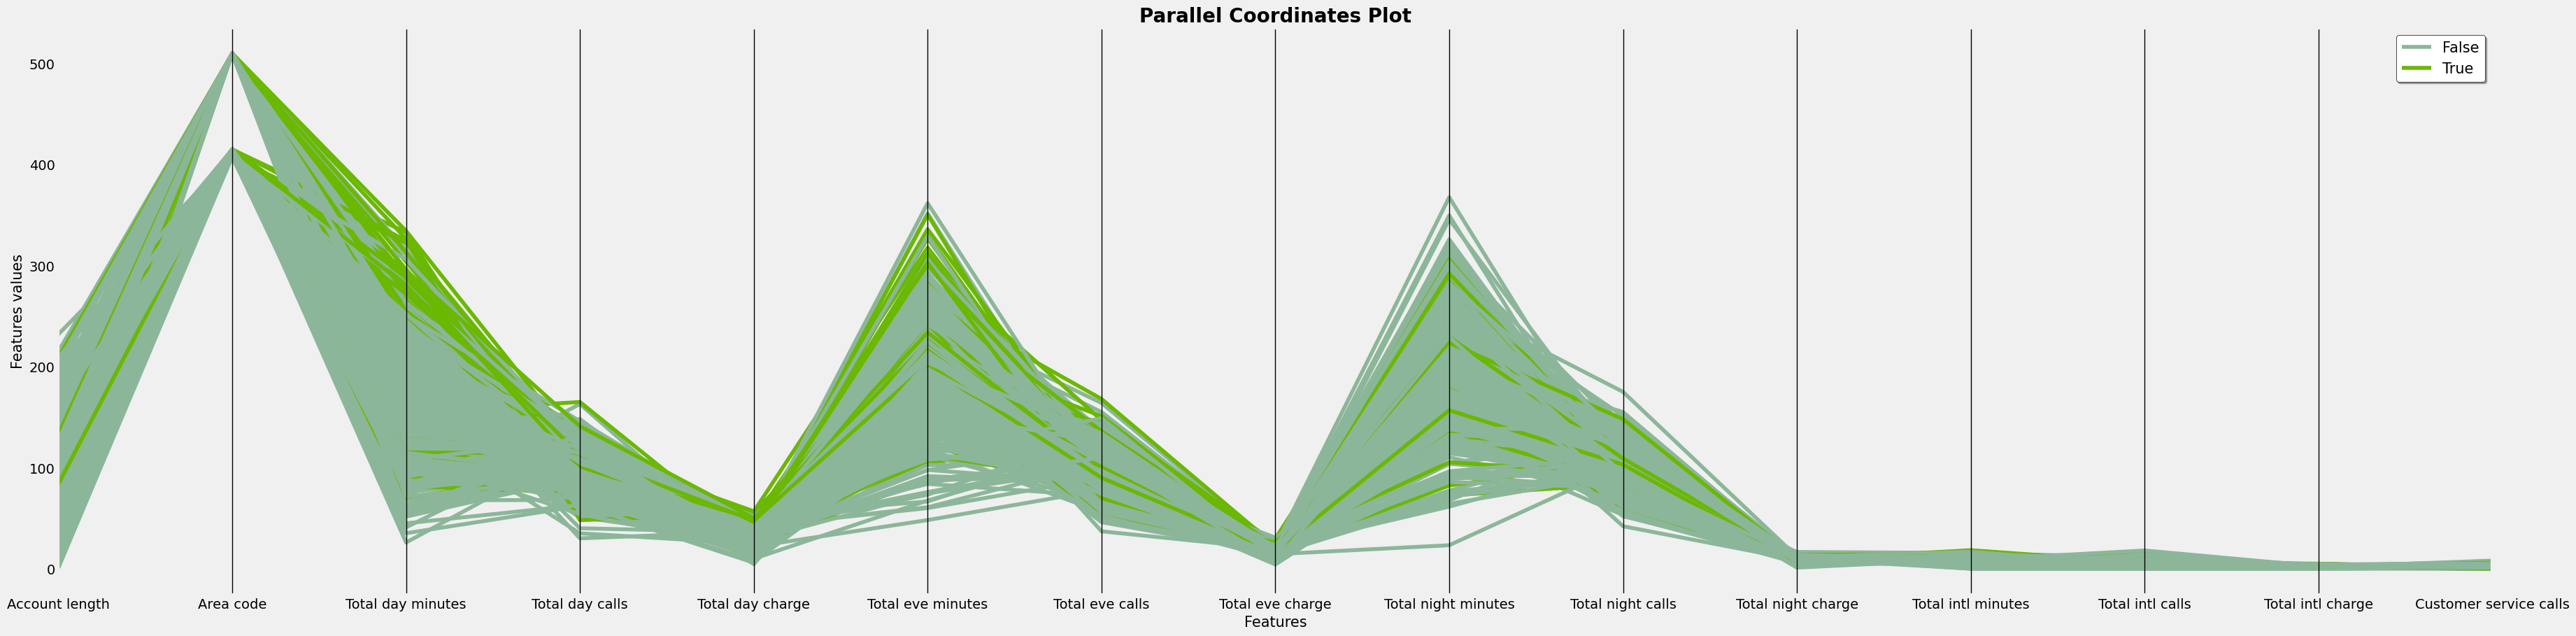

In [ ]:
# We are going to import a function from the plotting sub-library in Pandas
# and use it to create the graph for all the variables in the file so we can compare everything

from pandas.plotting import parallel_coordinates
plt.figure(figsize=(40,10))
parallel_coordinates(dataset, "Churn")
plt.title('Parallel Coordinates Plot', fontsize=20, fontweight='bold')
plt.xlabel('Features', fontsize=15)
plt.ylabel('Features values', fontsize=15)
plt.legend(loc=1, prop={'size': 15}, frameon=True,shadow=True, facecolor="white", edgecolor="black")
plt.show()

#### Result
Most of the variables don't have a very large difference between the customers that left and stayed but we can see the different time call minutes tend to be higher so we can plot this graph again to focus on the variable we found interesting.

####

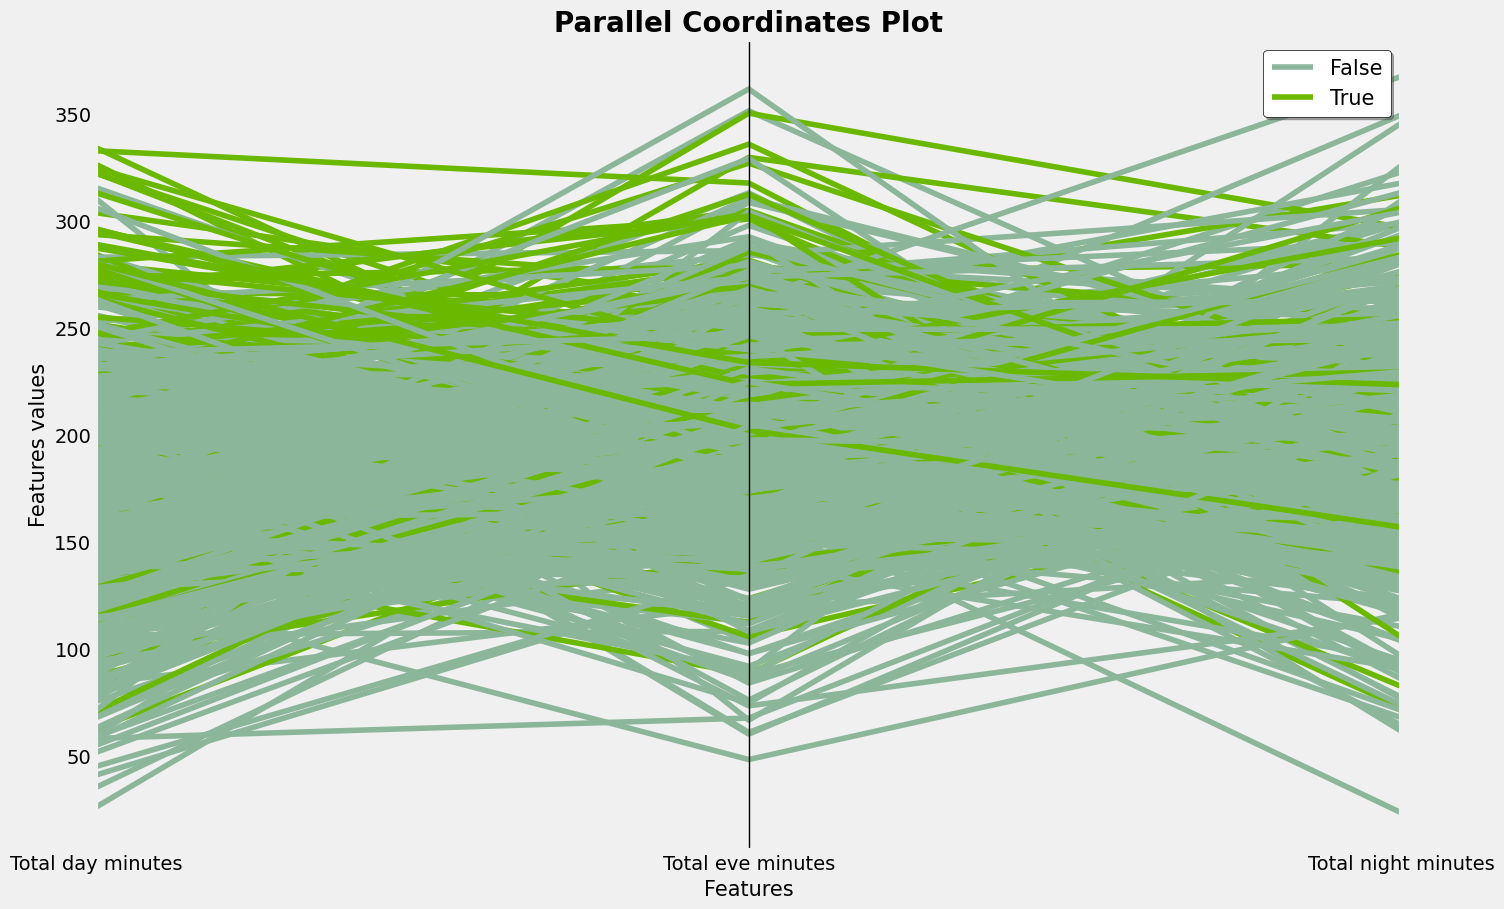

In [ ]:
#This creates the same graph from earlier but there are going to be focused on
# the minutes of calls over the differen times of the day
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(15,10))
parallel_coordinates(dataset_callMin, "Churn")
plt.title('Parallel Coordinates Plot', fontsize=20, fontweight='bold')
plt.xlabel('Features', fontsize=15)
plt.ylabel('Features values', fontsize=15)
plt.legend(loc=1, prop={'size': 15}, frameon=True,shadow=True, facecolor="white", edgecolor="black")
plt.show()

#### Result
This graph shows us a closer look at the selected variables and we can see that the customers that left are at the top of with the higher duration of calls.

Next we are going to focus on the count of the calls and see if there is anything we can extrapolate from a graph.

<Axes: ylabel='Frequency'>

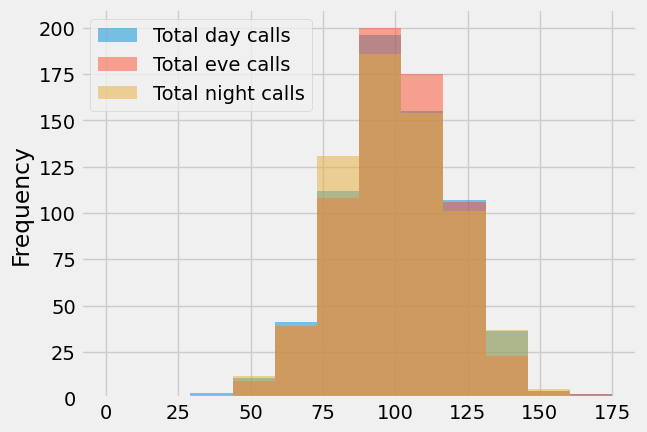

In [ ]:
#This graph visualizes the distribution of the different call counts throughout
# the day and we can see that there is a lot of similarities
dataset_callCount.plot.hist(bins=12, alpha=0.5)

<Figure size 640x480 with 0 Axes>

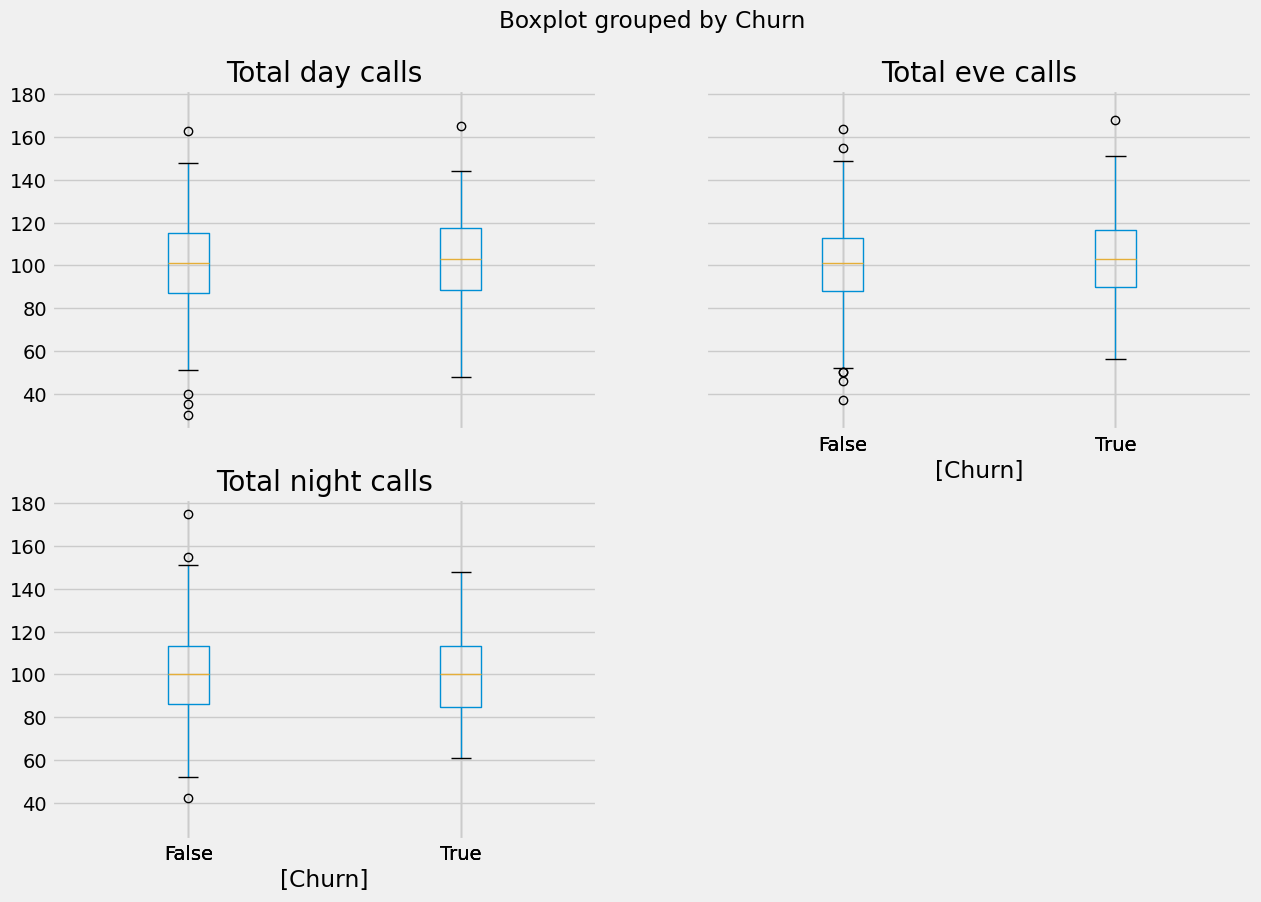

In [ ]:
# We are now going to see if there is a difference in the values of the counts
# when we seperate them by the churn values of the observations

#We are going to creat a boxplot for adding the dependent variable to the call
# counts
#We see that there is no significant difference between the values in the dependent
# variables so we can infer that they will have less importance in the building
# of the model

plt.figure()
dataset_callCount.boxplot(by="Churn", figsize=(15, 10))
plt.show()

## Using KNN for classification

#### Model Building
Now we have a rough idea of the variables we want to select and build the model for classifications of the values and we are going to test the accuracy of the model after the build.


In [ ]:
# We are going to import other functions that are going to help us build the model

# Loading different libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

# Instantiate learning model (k = 3)
# There is no ideal value for K and it is selected after testing and evaluation.
# We'll start with 3. 5 is also a common starting point.
classifier = KNeighborsClassifier(n_neighbors=3)

# Fitting the model with the traning portion of the data from the file
classifier.fit(X_train, y_train)

# Predicting the Test set results and storing it in a variable
y_pred = classifier.predict(X_test)

In [ ]:
# We are now going to test the predictions of the model to the values we know to
# be true in the file

# The confusion metrix shows us how currate the model was by displaying how many
# of each answer were true

#The frist column is the values of false(0) or true (1)
#The second column is the false predictions, so 116 were correctly lables false while
#     12 were incorrectly labled as false
#The third column is the true predictions, so 1 was incorrectly labled as true and
#     5 were correctly labled as true
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)


Predicted,0,1,All
True,,,
0,116,1,117
1,12,5,17
All,128,6,134


In [ ]:
#Now we are goin to print the accuracy of the model.
#We get this value by comparing the predicted values with what we know to be true

#this is an imported function that can do the calculation for us
accuracy  = accuracy_score(y_test, y_pred)
print ("Accuracy of the model : ", round (accuracy * 100, 2), "%")

Accuracy of the model :  90.3 %


#### Cross-Validation
Normally in machine learning, the data set is divided into training and testing sets. We use the training data to train the model and the testing set to evaluate performance. This may lead to problems in variance, however, which is when different combinations of training/testing sets lead to different results.

For this reason, we perform cross-validation. GridSearchCV is one form of cross-validation provided by Scikit Learn. We're basically going to send a dictionary of parameters, defined below as param_grid, defining our model (n_neighbors) and sending various values for K, number of neighbors. Then we re-run the model with a subsets of the data. In the case below, cv=5 means that we are conducting a 5-fold cross validation. We will create 5 subsets of the data. In the first iteration (or 'fold'), sets 1-4 are used as the training set and set 5 as testing. In the second fold, sets 1-3 and 5 might be used for training and set 4 for testing, and so on. At any rate, rotating through various sets helps us to conduct cross-validation and reduce variance.



In [ ]:
#import GridSearchCV and build the model
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [ ]:
#print the best score obtained during GridSearchCV
knn_cv.best_score_


np.float64(0.8785658175288968)

In [ ]:
# and the optimal number of neighbors (note different techniques may identify different results for 'optimal number')
knn_cv.best_params_

{'n_neighbors': np.int64(10)}

#### Optimal K value
We want to find out the optimal number of features to include.

In [ ]:
#creating list of K for KNN
k_list = list(range(1,50,2))
# creating list of cv scores
cv_scores = []

# perform 10-fold cross validation
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

<Figure size 640x480 with 0 Axes>

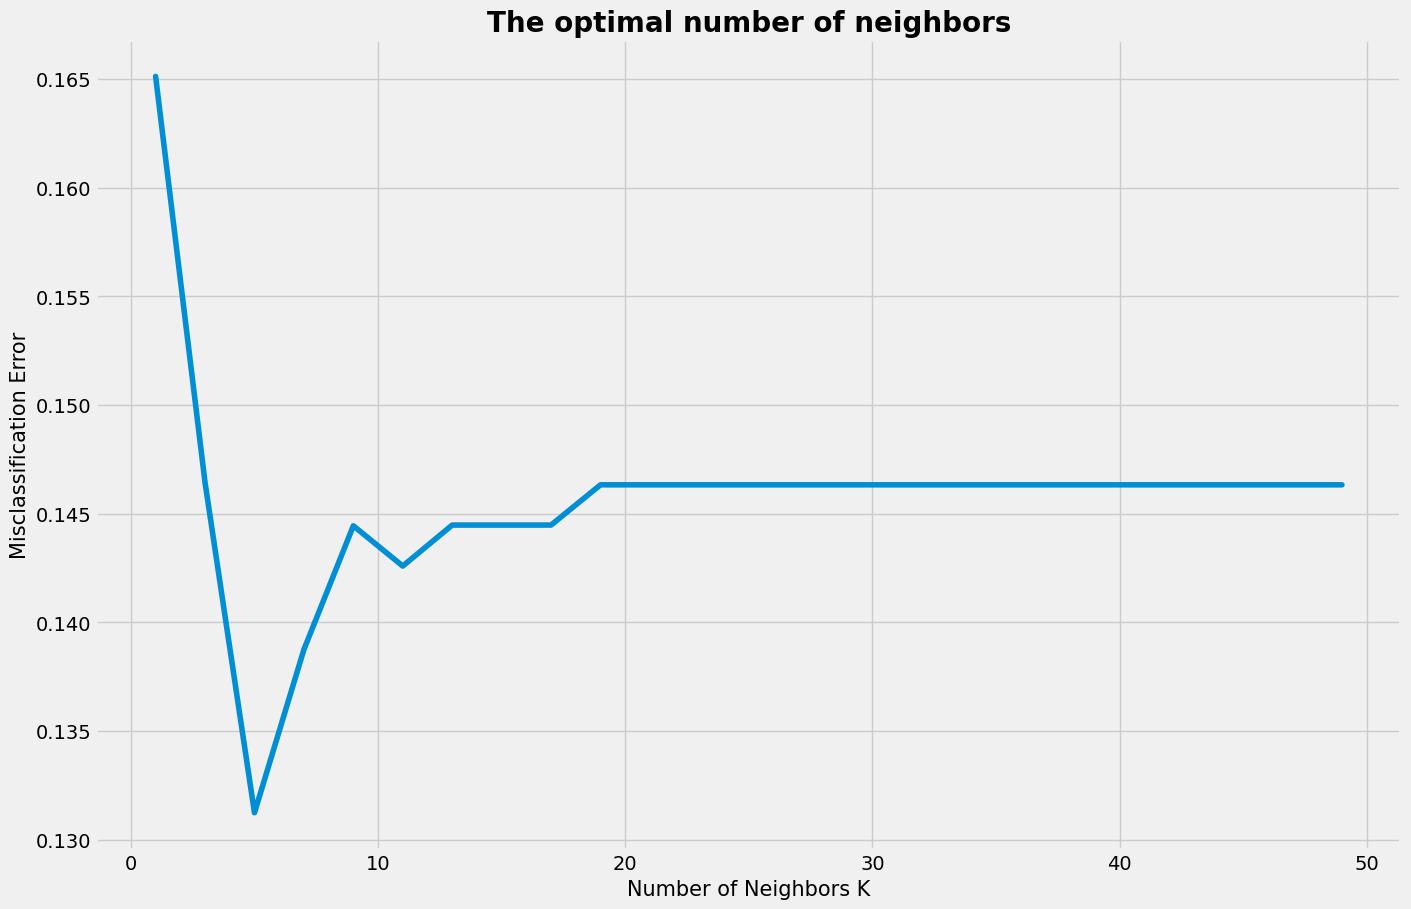

In [ ]:
# changing to misclassification error
MSE = [1 - x for x in cv_scores]

plt.figure()
plt.figure(figsize=(15,10))
plt.title('The optimal number of neighbors', fontsize=20, fontweight='bold')
plt.xlabel('Number of Neighbors K', fontsize=15)
plt.ylabel('Misclassification Error', fontsize=15)
sns.set_style("whitegrid")
plt.plot(k_list, MSE)

plt.show()

In [ ]:
# finding best k
best_k = k_list[MSE.index(min(MSE))]
print("The optimal number of neighbors is %d." % best_k)

The optimal number of neighbors is 5.
